# Supervised Machine Learning – Online Shopping Prediction

## 1. Syfte och frågeställning
## 2. Importera bibliotek och data
## 3. Förstå datasetet
## 4. EDA – undersöka variabler och relationer
## 5. Förbereda data för modellering
## 6. Modell 1: Logistic Regression
## 7. Modell 2: KNN
## 8. Modell 3: PCA + KNN eller PCA + Logistic Regression
## 9. Jämförelse av modeller
## 10. Slutsats och databerättelse

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

In [3]:
train_df = pd.read_csv("../../data/training_sample_svenska.csv")
test_df = pd.read_csv("../../data/testing_sample_svenska.csv")

train_df.head()

,anvandar_id,klickat_varukorgsikon,lagt_till_fran_kategorisida,lagt_till_fran_produktsida,anvant_sorteringsfunktion,klickat_pa_produktbild,gatt_in_pa_kontosida,klickat_pa_kampanjbanner,sparat_i_onskelista,anvant_prissortering,...,gatt_till_produktspecifikation,gatt_till_leveransvillkor,tomt_varukorg,gatt_till_startsidan,anvant_mobil,anvant_dator,anvant_surfplatta,aterkommande_besokare,besokt_fran_svensk_plats,genomfort_bestallning
0,a720-6b732349-a720-4862-bd21-644732,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,a0c0-6b73247c-a0c0-4bd9-8baa-797356,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,86a8-6b735c67-86a8-407b-ba24-333055,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
3,6a3d-6b736346-6a3d-4085-934b-396834,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
4,b74a-6b737717-b74a-45c3-8c6a-421140,0,1,0,1,0,0,0,0,1,...,0,0,0,1,0,0,1,0,1,1


In [4]:
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

train_df.info()

Training shape: (455401, 25)
Testing shape: (151655, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455401 entries, 0 to 455400
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   anvandar_id                     455401 non-null  object
 1   klickat_varukorgsikon           455401 non-null  int64 
 2   lagt_till_fran_kategorisida     455401 non-null  int64 
 3   lagt_till_fran_produktsida      455401 non-null  int64 
 4   anvant_sorteringsfunktion       455401 non-null  int64 
 5   klickat_pa_produktbild          455401 non-null  int64 
 6   gatt_in_pa_kontosida            455401 non-null  int64 
 7   klickat_pa_kampanjbanner        455401 non-null  int64 
 8   sparat_i_onskelista             455401 non-null  int64 
 9   anvant_prissortering            455401 non-null  int64 
 10  stangt_liten_varukorg_popup     455401 non-null  int64 
 11  kollat_fraktkostnad             45

In [5]:
train_df.describe()

,klickat_varukorgsikon,lagt_till_fran_kategorisida,lagt_till_fran_produktsida,anvant_sorteringsfunktion,klickat_pa_produktbild,gatt_in_pa_kontosida,klickat_pa_kampanjbanner,sparat_i_onskelista,anvant_prissortering,stangt_liten_varukorg_popup,...,gatt_till_produktspecifikation,gatt_till_leveransvillkor,tomt_varukorg,gatt_till_startsidan,anvant_mobil,anvant_dator,anvant_surfplatta,aterkommande_besokare,besokt_fran_svensk_plats,genomfort_bestallning
count,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,...,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000,455401.000000
mean,0.099150,0.074521,0.112916,0.036849,0.026735,0.003570,0.016208,0.003511,0.230362,0.017277,...,0.000389,0.005542,0.001096,0.290024,0.680706,0.194220,0.128364,0.534915,0.933224,0.041926
std,0.298864,0.262617,0.316490,0.188391,0.161307,0.059647,0.126274,0.059151,0.421065,0.130302,...,0.019711,0.074241,0.033084,0.453773,0.466204,0.395599,0.334495,0.498780,0.249634,0.200420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
train_df.isnull().sum()

anvandar_id                       0
klickat_varukorgsikon             0
lagt_till_fran_kategorisida       0
lagt_till_fran_produktsida        0
anvant_sorteringsfunktion         0
klickat_pa_produktbild            0
gatt_in_pa_kontosida              0
klickat_pa_kampanjbanner          0
sparat_i_onskelista               0
anvant_prissortering              0
stangt_liten_varukorg_popup       0
kollat_fraktkostnad               0
kollat_angerratt                  0
loggat_in                         0
gatt_till_kassan                  0
gatt_till_produktspecifikation    0
gatt_till_leveransvillkor         0
tomt_varukorg                     0
gatt_till_startsidan              0
anvant_mobil                      0
anvant_dator                      0
anvant_surfplatta                 0
aterkommande_besokare             0
besokt_fran_svensk_plats          0
genomfort_bestallning             0
dtype: int64

Datasetet innehåller information om användarbeteenden på en webbshop. Varje rad representerar en besökare/session och variablerna visar olika klick eller handlingar, till exempel om personen klickade på varukorgen, loggade in, gick till kassan eller använde mobil/dator. Målvariabeln är `genomfort_bestallning`, som visar om besökaren faktiskt genomförde en beställning eller inte.

In [7]:
train_df["genomfort_bestallning"].value_counts()

genomfort_bestallning
0    436308
1     19093
Name: count, dtype: int64

In [8]:
train_df["genomfort_bestallning"].value_counts(normalize=True) * 100

genomfort_bestallning
0    95.807431
1     4.192569
Name: proportion, dtype: float64

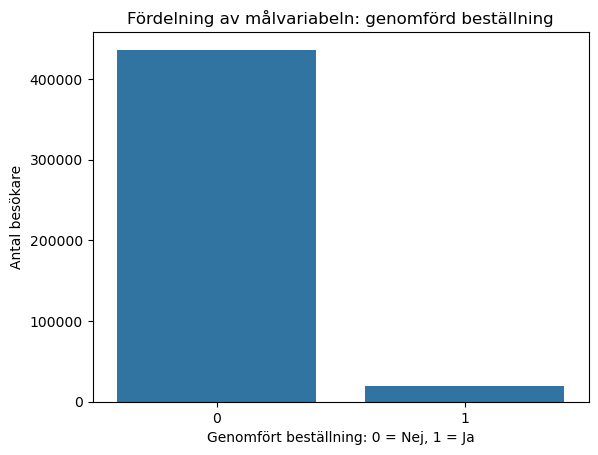

In [9]:
sns.countplot(data=train_df, x="genomfort_bestallning")
plt.title("Fördelning av målvariabeln: genomförd beställning")
plt.xlabel("Genomfört beställning: 0 = Nej, 1 = Ja")
plt.ylabel("Antal besökare")
plt.show()

Här ser vi att datasetet är obalanserat. De flesta besökare genomför inte en beställning, medan en mindre andel faktiskt beställer. Därför räcker det inte att bara titta på accuracy. Vi behöver också titta på precision, recall, F1-score och gärna Precision-Recall-kurva.

Kan vi förstå vilka klickbeteenden som visar att en kund är nära att köpa?

Vi analyserar besökarnas beteende på en webbshop. Vissa handlingar, som att gå till kassan, logga in eller lägga till varor, kan vara starka signaler på köpintention. Med supervised machine learning testar vi om modellen kan lära sig dessa mönster och förutsäga om en besökare kommer att genomföra en beställning.

In [10]:
X = train_df.drop(columns=["anvandar_id", "genomfort_bestallning"])
y = train_df["genomfort_bestallning"]

X.head()

,klickat_varukorgsikon,lagt_till_fran_kategorisida,lagt_till_fran_produktsida,anvant_sorteringsfunktion,klickat_pa_produktbild,gatt_in_pa_kontosida,klickat_pa_kampanjbanner,sparat_i_onskelista,anvant_prissortering,stangt_liten_varukorg_popup,...,gatt_till_kassan,gatt_till_produktspecifikation,gatt_till_leveransvillkor,tomt_varukorg,gatt_till_startsidan,anvant_mobil,anvant_dator,anvant_surfplatta,aterkommande_besokare,besokt_fran_svensk_plats
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
4,0,1,0,1,0,0,0,0,1,0,...,1,0,0,0,1,0,0,1,0,1


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_val distribution:")
print(y_val.value_counts(normalize=True))

X_train: (364320, 23)
X_val: (91081, 23)
y_train distribution:
genomfort_bestallning
0    0.958075
1    0.041925
Name: proportion, dtype: float64
y_val distribution:
genomfort_bestallning
0    0.95807
1    0.04193
Name: proportion, dtype: float64


In [12]:
features = X.columns

conversion_rates = []

for col in features:
    rate_when_0 = train_df[train_df[col] == 0]["genomfort_bestallning"].mean()
    rate_when_1 = train_df[train_df[col] == 1]["genomfort_bestallning"].mean()
    diff = rate_when_1 - rate_when_0
    
    conversion_rates.append({
        "variabel": col,
        "köpandel_när_0": rate_when_0,
        "köpandel_när_1": rate_when_1,
        "skillnad": diff
    })

conversion_df = pd.DataFrame(conversion_rates)
conversion_df = conversion_df.sort_values("skillnad", ascending=False)

conversion_df.head(10)

,variabel,köpandel_när_0,köpandel_när_1,skillnad
10,kollat_fraktkostnad,0.000462,0.659938,0.659476
13,gatt_till_kassan,0.000000,0.523512,0.523512
12,loggat_in,0.000282,0.469192,0.468910
0,klickat_varukorgsikon,0.013446,0.300689,0.287243
2,lagt_till_fran_produktsida,0.012293,0.274727,0.262434
1,lagt_till_fran_kategorisida,0.025566,0.245101,0.219536
9,stangt_liten_varukorg_popup,0.038205,0.253559,0.215354
5,gatt_in_pa_kontosida,0.041238,0.233702,0.192464
16,tomt_varukorg,0.041754,0.198397,0.156643
11,kollat_angerratt,0.040778,0.165789,0.125011


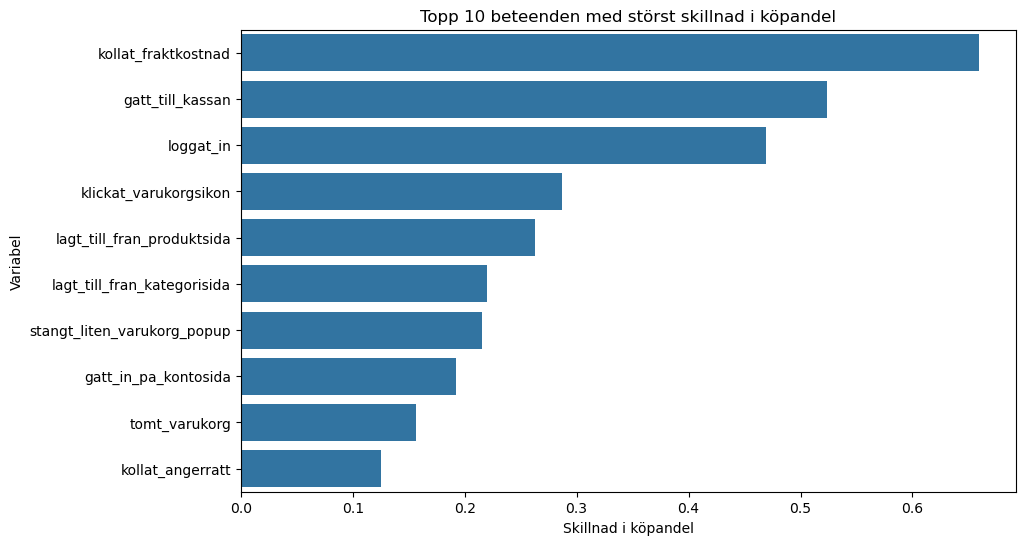

In [13]:
top_10 = conversion_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x="skillnad", y="variabel")
plt.title("Topp 10 beteenden med störst skillnad i köpandel")
plt.xlabel("Skillnad i köpandel")
plt.ylabel("Variabel")
plt.show()

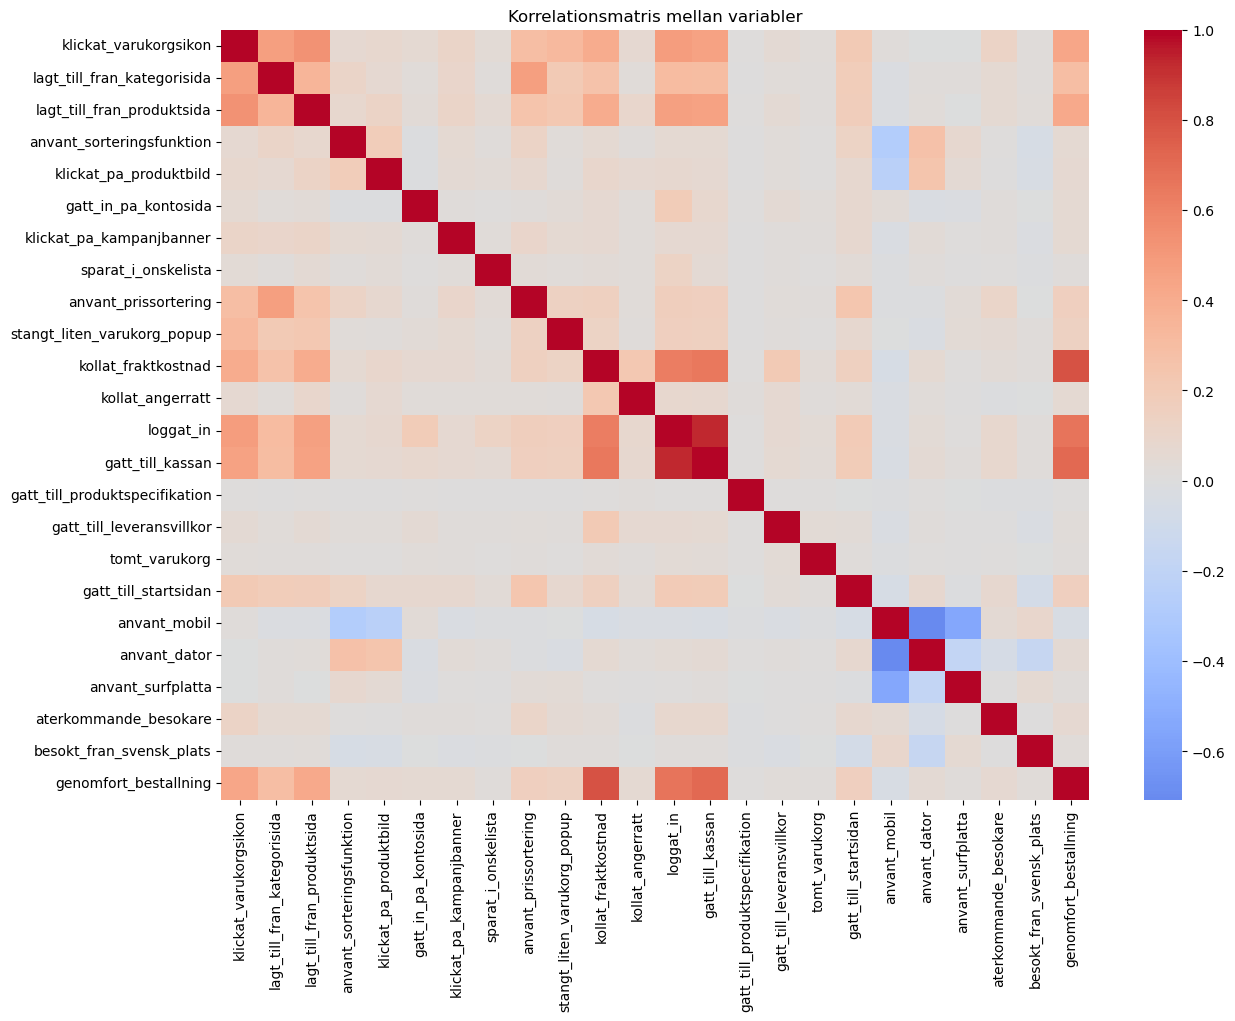

In [14]:
corr = train_df.drop(columns=["anvandar_id"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Korrelationsmatris mellan variabler")
plt.show()

In [15]:
target_corr = corr["genomfort_bestallning"].sort_values(ascending=False)

target_corr

genomfort_bestallning             1.000000
kollat_fraktkostnad               0.798720
gatt_till_kassan                  0.708986
loggat_in                         0.665556
klickat_varukorgsikon             0.428334
lagt_till_fran_produktsida        0.414420
lagt_till_fran_kategorisida       0.287666
gatt_till_startsidan              0.157778
anvant_prissortering              0.154867
stangt_liten_varukorg_popup       0.140011
klickat_pa_produktbild            0.071492
aterkommande_besokare             0.060295
kollat_angerratt                  0.059484
gatt_in_pa_kontosida              0.057279
klickat_pa_kampanjbanner          0.056533
anvant_sorteringsfunktion         0.054636
anvant_dator                      0.049208
besokt_fran_svensk_plats          0.031643
gatt_till_leveransvillkor         0.031461
tomt_varukorg                     0.025857
sparat_i_onskelista               0.023516
anvant_surfplatta                 0.016939
gatt_till_produktspecifikation    0.007548
anvant_mobi

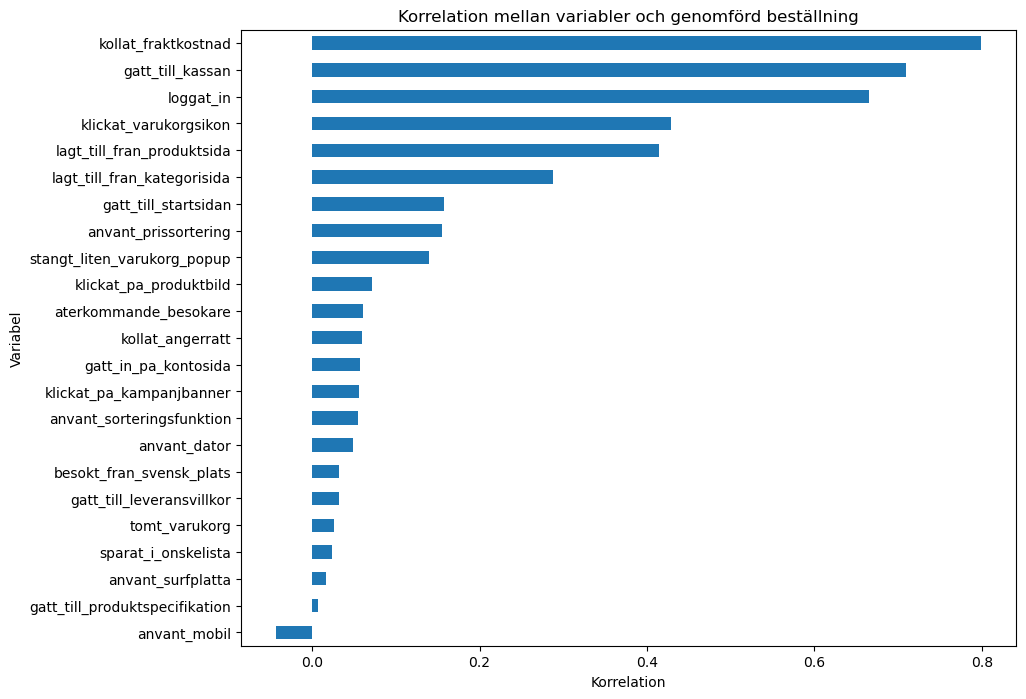

In [16]:
target_corr.drop("genomfort_bestallning").sort_values().plot(kind="barh", figsize=(10, 8))
plt.title("Korrelation mellan variabler och genomförd beställning")
plt.xlabel("Korrelation")
plt.ylabel("Variabel")
plt.show()

Målvariabeln `genomfort_bestallning` är tydligt obalanserad. Cirka 95.8 % av besökarna genomförde inte en beställning, medan endast cirka 4.2 % gjorde det. Det betyder att modellen kan få hög accuracy genom att nästan alltid förutsäga klass 0. Därför behöver vi använda flera utvärderingsmått, särskilt precision, recall och F1-score för klass 1.

Korrelationsanalysen visar samma mönster som köpandelsanalysen. Variabler som `kollat_fraktkostnad`, `gatt_till_kassan` och `loggat_in` har starkast positiv korrelation med målvariabeln `genomfort_bestallning`. Det betyder att dessa beteenden är viktiga indikatorer för om en besökare kommer att genomföra en beställning.

EDA:n visar att vissa beteenden har en mycket stark relation till genomförd beställning. Den tydligaste variabeln är `kollat_fraktkostnad`, där köpandelen är mycket högre bland besökare som har kontrollerat fraktkostnad. Även `gatt_till_kassan`, `loggat_in`, `klickat_varukorgsikon` och `lagt_till_fran_produktsida` verkar vara starka signaler på köpintention.

Detta är logiskt ur ett webbshop-perspektiv. En besökare som kontrollerar fraktkostnad, går till kassan eller loggar in har troligen kommit längre i köpresan än en besökare som bara tittar runt på sidan.

Här ser vi att alla klick inte betyder samma sak. Att bara besöka sidan är svagare signal, men att gå till kassan, logga in eller kolla fraktkostnad visar att kunden är mycket närmare ett köp.

In [17]:
# Skala data för Logistic Regression och KNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [18]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_val_scaled)
y_proba_log = log_model.predict_proba(X_val_scaled)[:, 1]

In [19]:
print("Accuracy:", accuracy_score(y_val, y_pred_log))
print("Precision:", precision_score(y_val, y_pred_log))
print("Recall:", recall_score(y_val, y_pred_log))
print("F1-score:", f1_score(y_val, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_log))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_log))

Accuracy: 0.9920400522611741
Precision: 0.8450044603033007
Recall: 0.9921445404556166
F1-score: 0.9126821630735878
ROC-AUC: 0.9973997353450771

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.85      0.99      0.91      3819

    accuracy                           0.99     91081
   macro avg       0.92      0.99      0.95     91081
weighted avg       0.99      0.99      0.99     91081



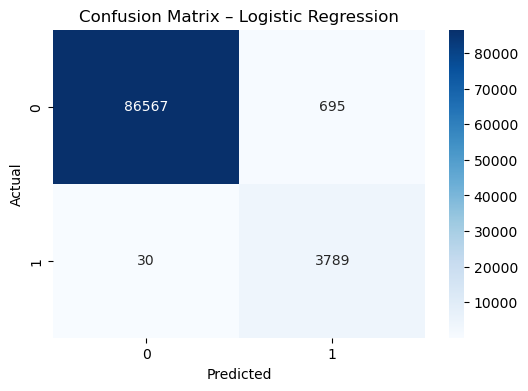

In [20]:
cm = confusion_matrix(y_val, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

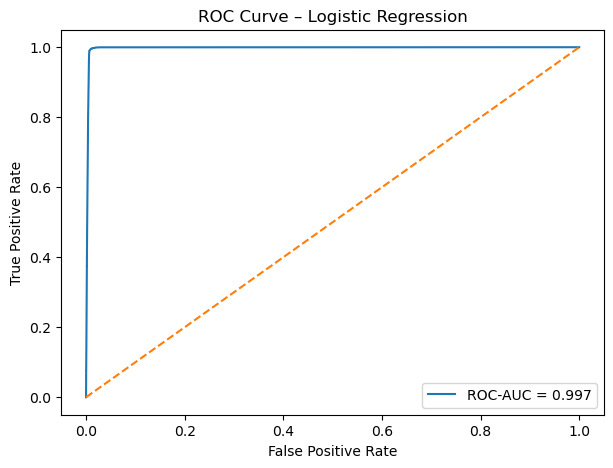

In [21]:
fpr, tpr, thresholds = roc_curve(y_val, y_proba_log)
auc_score = roc_auc_score(y_val, y_proba_log)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve – Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Modellen presterar väldigt bra, men vi behöver komma ihåg att vissa variabler är mycket nära själva köptillfället, till exempel att gå till kassan eller kontrollera fraktkostnad. Därför är modellen stark, men resultatet ska tolkas i relation till kundresan.

##  Modell 2: KNN

I den här delen testar jag K-Nearest Neighbors (KNN) som en andra supervised learning-modell.  
KNN jämför nya datapunkter med de närmaste datapunkterna i träningsdatan. Eftersom KNN är avståndsbaserad behöver datan skalas innan modellen tränas.

In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_val_scaled)
y_proba_knn = knn_model.predict_proba(X_val_scaled)[:, 1]

In [23]:
print("KNN Results")
print("Accuracy:", accuracy_score(y_val, y_pred_knn))
print("Precision:", precision_score(y_val, y_pred_knn))
print("Recall:", recall_score(y_val, y_pred_knn))
print("F1-score:", f1_score(y_val, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_knn))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_knn))

KNN Results
Accuracy: 0.9919302598785696
Precision: 0.8692528735632183
Recall: 0.950510604870385
F1-score: 0.9080675422138836
ROC-AUC: 0.9921975436374759

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.87      0.95      0.91      3819

    accuracy                           0.99     91081
   macro avg       0.93      0.97      0.95     91081
weighted avg       0.99      0.99      0.99     91081



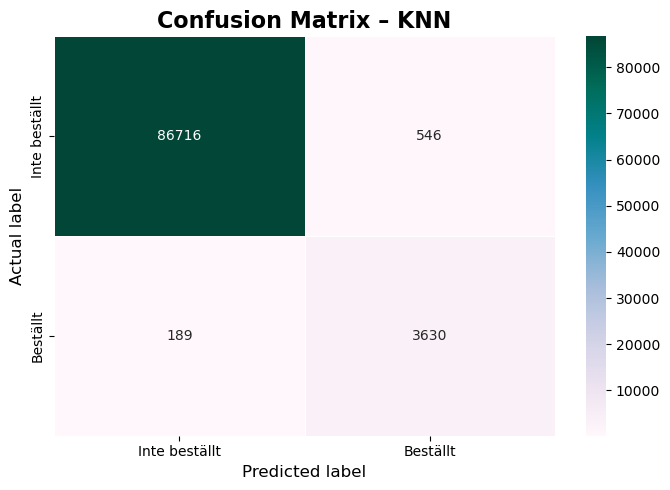

In [24]:
cm_knn = confusion_matrix(y_val, y_pred_knn)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="PuBuGn",
    linewidths=0.5,
    linecolor="white",
    xticklabels=["Inte beställt", "Beställt"],
    yticklabels=["Inte beställt", "Beställt"]
)

plt.title("Confusion Matrix – KNN", fontsize=16, fontweight="bold")
plt.xlabel("Predicted label", fontsize=12)
plt.ylabel("Actual label", fontsize=12)
plt.tight_layout()
plt.show()

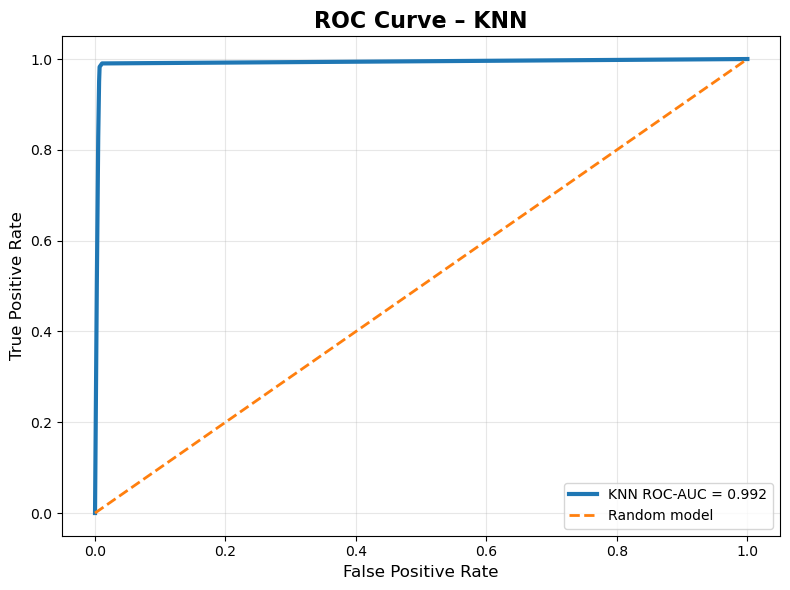

In [25]:
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_val, y_proba_knn)
auc_knn = roc_auc_score(y_val, y_proba_knn)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_knn,
    tpr_knn,
    linewidth=3,
    label=f"KNN ROC-AUC = {auc_knn:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random model"
)

plt.title("ROC Curve – KNN", fontsize=16, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Logistic Regression:
Accuracy: 0.9920
Precision: 0.8450
Recall: 0.9921
F1-score: 0.9127
ROC-AUC: 0.9974

KNN:
Accuracy: 0.9919
Precision: 0.8693
Recall: 0.9505
F1-score: 0.9081
ROC-AUC: 0.9922

### Tolkning av KNN-resultatet

KNN-modellen presterar mycket bra på validation-datan. Modellen får hög accuracy, hög precision och hög recall för klass 1, vilket betyder att den kan identifiera många av de besökare som faktiskt genomför en beställning.

Jämfört med Logistic Regression har KNN något högre precision men lägre recall. Det betyder att KNN är något mer försiktig när den förutsäger beställning, medan Logistic Regression hittar fler av de faktiska beställningarna.

Eftersom datasetet är obalanserat är recall och F1-score för klass 1 extra viktiga. Både Logistic Regression och KNN fungerar bra, men Logistic Regression verkar vara något starkare totalt eftersom den har högre recall och ROC-AUC.

In [26]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_score(y_val, y_pred_log),
        accuracy_score(y_val, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_val, y_pred_log),
        precision_score(y_val, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_val, y_pred_log),
        recall_score(y_val, y_pred_knn)
    ],
    "F1-score": [
        f1_score(y_val, y_pred_log),
        f1_score(y_val, y_pred_knn)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_proba_log),
        roc_auc_score(y_val, y_proba_knn)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.99204,0.845004,0.992145,0.912682,0.997400
1,KNN,0.99193,0.869253,0.950511,0.908068,0.992198


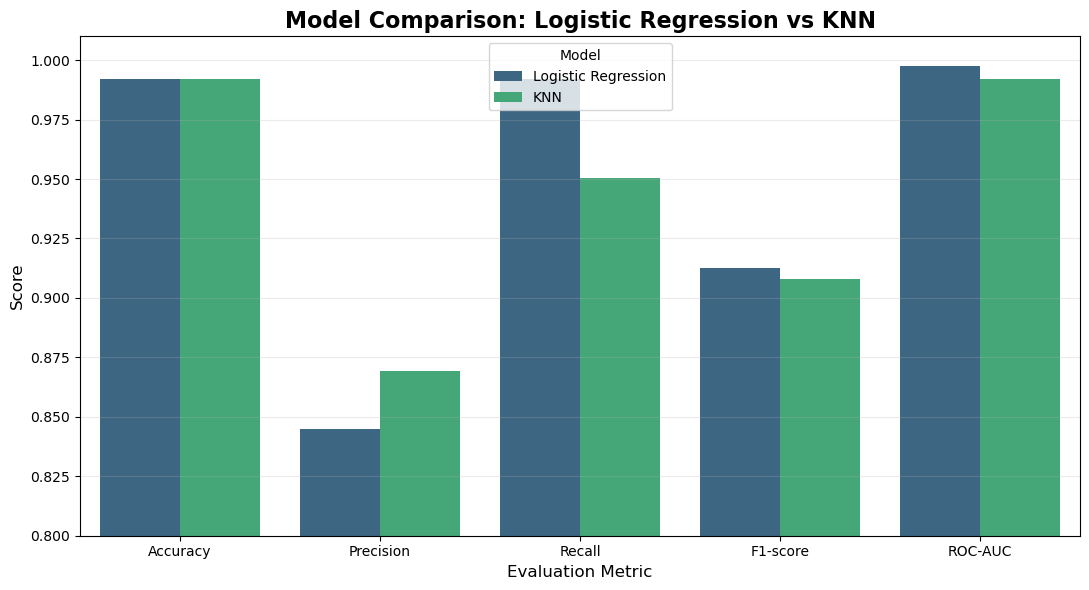

In [27]:
comparison_long = model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette="viridis"
)

plt.title("Model Comparison: Logistic Regression vs KNN", fontsize=16, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.80, 1.01)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Jämförelse mellan Logistic Regression och KNN

Båda modellerna presterar mycket bra på validation-datan. KNN har något högre precision, vilket betyder att modellen är lite mer säker när den förutsäger att en besökare kommer att genomföra en beställning.

Logistic Regression har däremot högre recall och ROC-AUC. Det betyder att Logistic Regression hittar fler av de faktiska beställningarna och är bättre på att skilja mellan klass 0 och klass 1.

Eftersom datasetet är obalanserat och klass 1 är den viktigaste klassen i detta case, är recall och F1-score extra viktiga. Därför bedömer jag att Logistic Regression är den starkaste modellen hittills.

##  PCA + KNN

I den här delen kombinerar jag PCA med KNN. PCA används för att minska antalet dimensioner i datan och behålla så mycket information som möjligt. Eftersom KNN är avståndsbaserad kan PCA ibland hjälpa modellen genom att minska brus och göra avståndsberäkningen mer stabil.

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_.sum())

Original number of features: 23
Number of PCA components: 19
Explained variance ratio: 0.9623908603122668


In [29]:
knn_pca_model = KNeighborsClassifier(n_neighbors=5)

knn_pca_model.fit(X_train_pca, y_train)

y_pred_knn_pca = knn_pca_model.predict(X_val_pca)
y_proba_knn_pca = knn_pca_model.predict_proba(X_val_pca)[:, 1]

In [30]:
print("KNN + PCA Results")
print("Accuracy:", accuracy_score(y_val, y_pred_knn_pca))
print("Precision:", precision_score(y_val, y_pred_knn_pca))
print("Recall:", recall_score(y_val, y_pred_knn_pca))
print("F1-score:", f1_score(y_val, y_pred_knn_pca))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_knn_pca))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_knn_pca))

KNN + PCA Results
Accuracy: 0.9916777373985793
Precision: 0.8695967157691379
Recall: 0.942916993977481
F1-score: 0.9047738693467337
ROC-AUC: 0.9911273645800135

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     87262
           1       0.87      0.94      0.90      3819

    accuracy                           0.99     91081
   macro avg       0.93      0.97      0.95     91081
weighted avg       0.99      0.99      0.99     91081



### Tolkning av KNN + PCA

KNN + PCA presterar fortfarande mycket bra, men resultatet är något lägre än både Logistic Regression och vanlig KNN. Precisionen är ungefär på samma nivå som KNN, men recall och F1-score minskar något.

Det betyder att PCA inte förbättrade modellen i detta case. En möjlig förklaring är att datasetet redan har relativt få feature-variabler och att variablerna redan är binära och tydliga. När PCA komprimerar informationen kan vissa små men viktiga signaler för klass 1 försvagas.

Därför verkar PCA inte vara nödvändigt för detta dataset, även om det var värdefullt att testa metoden.

In [31]:
final_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "KNN + PCA"],
    "Accuracy": [
        accuracy_score(y_val, y_pred_log),
        accuracy_score(y_val, y_pred_knn),
        accuracy_score(y_val, y_pred_knn_pca)
    ],
    "Precision": [
        precision_score(y_val, y_pred_log),
        precision_score(y_val, y_pred_knn),
        precision_score(y_val, y_pred_knn_pca)
    ],
    "Recall": [
        recall_score(y_val, y_pred_log),
        recall_score(y_val, y_pred_knn),
        recall_score(y_val, y_pred_knn_pca)
    ],
    "F1-score": [
        f1_score(y_val, y_pred_log),
        f1_score(y_val, y_pred_knn),
        f1_score(y_val, y_pred_knn_pca)
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_proba_log),
        roc_auc_score(y_val, y_proba_knn),
        roc_auc_score(y_val, y_proba_knn_pca)
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.992040,0.845004,0.992145,0.912682,0.997400
1,KNN,0.991930,0.869253,0.950511,0.908068,0.992198
2,KNN + PCA,0.991678,0.869597,0.942917,0.904774,0.991127


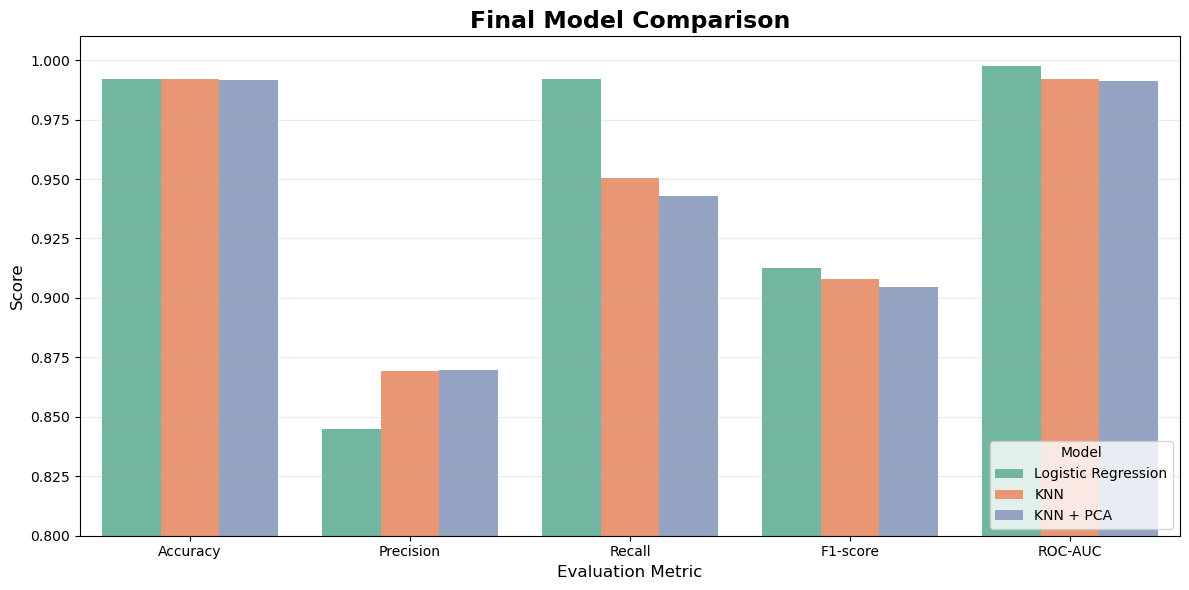

In [32]:
final_long = final_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=final_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette="Set2"
)

plt.title("Final Model Comparison", fontsize=17, fontweight="bold")
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0.80, 1.01)
plt.legend(title="Model", loc="lower right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

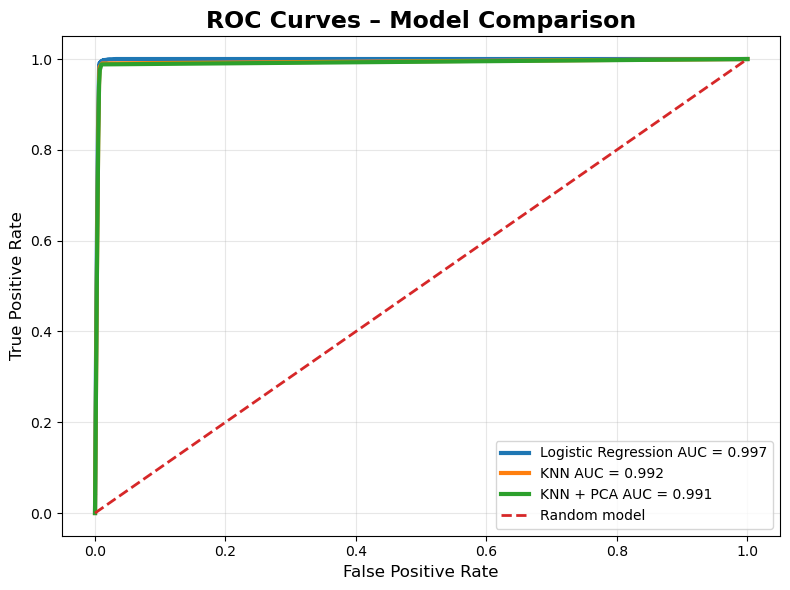

In [33]:
fpr_log, tpr_log, _ = roc_curve(y_val, y_proba_log)
fpr_knn, tpr_knn, _ = roc_curve(y_val, y_proba_knn)
fpr_knn_pca, tpr_knn_pca, _ = roc_curve(y_val, y_proba_knn_pca)

auc_log = roc_auc_score(y_val, y_proba_log)
auc_knn = roc_auc_score(y_val, y_proba_knn)
auc_knn_pca = roc_auc_score(y_val, y_proba_knn_pca)

plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, linewidth=3, label=f"Logistic Regression AUC = {auc_log:.3f}")
plt.plot(fpr_knn, tpr_knn, linewidth=3, label=f"KNN AUC = {auc_knn:.3f}")
plt.plot(fpr_knn_pca, tpr_knn_pca, linewidth=3, label=f"KNN + PCA AUC = {auc_knn_pca:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Random model")

plt.title("ROC Curves – Model Comparison", fontsize=17, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()